<!--- sf-header --->
<table align="left">
<tr>
  <td style="text-align: center">
    <a href="https://console.cloud.google.com/vertex-ai/colab/import/https%3A%2F%2Fraw.githubusercontent.com%2Fstatmike%2Fscale-forecasting%2Fmain%2Fnotebooks%2F08_run_and_monitor.ipynb">
      <img width="32px" src="https://lh3.googleusercontent.com/JmcxdQi-qOpctIvWKgPtrzZdJJK-J3sWE1RsfjZNwshCFgE_9fULcNpuXYTilIR2hjwN" alt="Colab Enterprise logo">
      <br>Run in<br>Colab Enterprise
    </a>
  </td>
</tr>
</table>
<br clear="left"/>

> **Run in Colab Enterprise:** click the badge to import this notebook, pick a runtime, and
> **Run all**. The Terraform-deployed templates already carry the `SF_*` run identity in their env,
> so there's no environment cell to fill in. Runs on the **`sf-main`** runtime template (Python 3.11). See
> [`docs/notebook_runtimes.md`](https://github.com/statmike/scale-forecasting/blob/main/docs/notebook_runtimes.md)
> for the per-notebook template mapping and the headless acceptance harness.


# 08 · Run and monitor — launch a multi-system run, watch it land

This notebook *launches* a run and then **watches it come in** — the live half of the job-review pair (its finished-run review is [09](09_review_run.ipynb)).

It assembles one config that mixes a **Spark** model (`theta`) with the **BigQuery-native** models (`arima_plus`, `timesfm`) and turns **backtest + ensembles on**, then submits it with `main.run` — both compute tracks **in parallel under one `run_id`**, the ensembler after the join.

`main.run` is **blocking** — it returns only when the whole run finishes — so calling it inline would freeze the notebook with nothing to watch. Instead we launch it on a **background thread** and, while it runs, poll `review.monitor_run(run_id)` on a loop, **redrawing the per-family progress dashboard in place** until the run reaches a terminal state.

The run is small (10 series) so it's quick and cheap — raise `SERIES_LIMIT` to scale the same config up. When it finishes, open **[09 · Review run](09_review_run.ipynb)** on the same `run_id` for the data-science review (leaderboard, metric distribution, ensemble lift, timeline).

## Get the code (cloud runtimes only)

On a cloud notebook (Colab Enterprise, Vertex Workbench) this clones or updates the repo so you're on the latest `src/`. **Skip it in a local clone** — it's a no-op guarded on the package already being importable.

In [1]:
# Cloud bootstrap: clone + install the LOCKED dependency set (uv.lock) so
# `import scale_forecasting` resolves against the exact versions every other surface runs.
# Uses uv (Colab ships it; we install it if missing) to install the frozen lock into a PRIVATE
# prefix, then puts that prefix + src/ first on sys.path. Harmless locally — if it already imports,
# no-op.
import importlib.util
import os
import shutil
import subprocess
import sys

REPO_URL = os.environ.get("SF_REPO_URL", "https://github.com/statmike/scale-forecasting.git")
REPO_DIR = os.environ.get("SF_REPO_DIR", "scale-forecasting")

EXTRAS = []  # this notebook needs only the core (the submit path lazy-imports the model stack)

if importlib.util.find_spec("scale_forecasting") is None:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    uv = shutil.which("uv")
    if uv is None:  # Colab Enterprise ships uv; install it if this runtime doesn't
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "uv"], check=True)
        uv = shutil.which("uv") or "uv"
    # Resolve the checked-in lock to a requirements file (no re-resolve), then install EXACTLY
    # that set into this kernel — the same versions the container + packed-venv are built from.
    reqs = os.path.abspath(os.path.join(REPO_DIR, "colab-requirements.txt"))
    extra_flags = [f for e in EXTRAS for f in ("--extra", e)]
    subprocess.run(
        [uv, "export", "--frozen", "--no-emit-project", "--no-hashes", "--no-dev", *extra_flags,
         "-o", reqs],
        cwd=REPO_DIR, check=True,
    )
    # Install the LOCKED set into a PRIVATE directory (not the runtime's system site-packages),
    # then put it FIRST on sys.path. Managed images (Colab Enterprise, Vertex) ship numpy 2.x that
    # can't be cleanly downgraded in place: uv skips the version-satisfied packages it can't fully
    # uninstall, so numpy-2 .so files end up beside numpy-1 python and `import numpy` dies with
    # "dtype size changed, Expected 96 ... got 88". Installing to a separate prefix and SHADOWING the
    # base packages (never touching them) gives this kernel a clean, self-consistent numpy 1.26.4 —
    # the same set every other surface runs — with zero risk of a mixed install.
    target = os.path.abspath(os.path.join(REPO_DIR, ".colab-deps"))
    subprocess.run(
        [uv, "pip", "install", "--python", sys.executable, "--target", target, "-r", reqs],
        check=True,
    )
    # src/ carries our package; `target` carries its locked deps. Both go ahead of the base image's
    # site-packages so imports resolve to the versions we installed, not the runtime's.
    sys.path.insert(0, target)
    sys.path.insert(0, os.path.join(REPO_DIR, "src"))

## Resolve the deployment (live GCP)

`Settings.resolve()` reads the `SF_*` environment — the *same* identity every writer uses, so a notebook run and a Composer run land in the same registry. Required: `SF_PROJECT_ID`, `SF_CONNECTION`, `SF_WAREHOUSE_URI`; `SF_DATASET_ID`/`SF_REGION` default.

In [2]:
from google.cloud import bigquery

from scale_forecasting.settings import Settings

settings = Settings.resolve()
client = bigquery.Client(project=settings.project_id)
DATASET = settings.dataset_ref
print("deployment:", DATASET, "region:", settings.region)

deployment: statmike-scale-forecasting.scale_forecasting region: us-central1


## Parameters — the run to launch

Everything that shapes the run is plain Python here, assembled into a **`RunConfig`** — the one frozen object that drives the run and is logged verbatim to `run_registry.raw_config`, so *this cell is the experiment record*.

- **`RUN_NAME`** carries a timestamp so each execution is its own clean run (a fresh `run_id` each time, so re-running never collides with a still-buffering prior run).
- **`MODELS`** mixes runtimes automatically: `theta` runs on **Spark**, `arima_plus`/`timesfm` in **BigQuery** — the router splits them by model, all under one `run_id`.
- **`BACKTEST=True`** emits an OOF metric panel and **`ENSEMBLE_STRATEGIES`** fires the ensembler after the join — so the run [09](09_review_run.ipynb) reviews has a populated accuracy view and ensemble lift.

We build the config, wrap it in a `Forecaster`, and read its `run_id` **before** launching — the id is a pure hash of the config, so we can start monitoring it immediately.

In [3]:
import time

from scale_forecasting import Forecaster
from scale_forecasting.config import RunConfig

# === Parameters — edit me ===============================================
RUN_NAME = f"nb08 run+monitor {int(time.time())}"  # timestamped → a fresh run each run
SOURCE_TABLE = "source_series_iceberg"  # shipped seed; _iceberg↔_native to compare storage
MODELS = ["theta", "arima_plus", "timesfm"]  # theta → Spark; arima_plus/timesfm → BigQuery
HORIZON = 28
SERIES_LIMIT = 10  # small subset so the demo is quick + cheap; raise to scale
HOLIDAYS = ["US"]
BACKTEST = True  # OOF panel so ensembles are scored (and 09's metric view is populated)
N_FOLDS = 2
ENSEMBLE_STRATEGIES = ["mean", "median", "inverse_error"]
# ========================================================================

cfg = RunConfig(
    run_name=RUN_NAME,
    python_runtime="spark",
    data={"source_table": SOURCE_TABLE, "horizon": HORIZON, "series_limit": SERIES_LIMIT},
    models=MODELS,  # router splits Spark vs BigQuery automatically
    features={"holidays": HOLIDAYS},
    backtest={"enabled": BACKTEST, "n_folds": N_FOLDS, "horizon": HORIZON, "step": HORIZON},
    ensemble={"enabled": True, "strategies": ENSEMBLE_STRATEGIES},
)
forecaster = Forecaster(cfg, settings=settings)
RUN_ID = forecaster.run_id  # pure config hash — known before the run starts
print("run_id:", RUN_ID)
print("  models:", cfg.models, "  ensemble:", cfg.ensemble.strategies)

run_id: nb08-run-monitor-1789936442-1a6aaebcac7f
  models: ['theta', 'arima_plus', 'timesfm']   ensemble: ['mean', 'median', 'inverse_error']


## Launch on a background thread

`main.run` blocks until the entire run finishes, so calling it inline would freeze the notebook until the end — nothing to monitor. Instead we run it on a **daemon thread**: it stages `src/` + the config, submits the Spark batch and the BigQuery jobs, and waits for the join — while the main kernel stays free to poll the registry. Any error from the run is captured and re-raised after the monitor loop, so a failed launch still surfaces (and the dashboard still renders its last state).

In [4]:
import threading

launch = {}  # collects the thread's result or error


def _launch():
    try:
        launch["result"] = forecaster.run()  # blocking: returns when the run finishes
    except Exception as exc:  # surfaced after the monitor loop so the dashboard still draws
        launch["error"] = exc


worker = threading.Thread(target=_launch, name="sf-run", daemon=True)
worker.start()
print(f"launched {RUN_ID} on a background thread — polling the registry below…")

launched nb08-run-monitor-1789936442-1a6aaebcac7f on a background thread — polling the registry below…


## Monitor — watch the run land, and escalate when a bar goes quiet

While the launch thread runs, this loop polls `monitor_run(run_id)` and **redraws the per-family progress dashboard in place** (`clear_output` + `plot_progress`): one bar per family, length = fraction of expected cells landed, colour = job status (green = completed, blue = running, gray = pending, vermillion = failed, amber = partial). It stops when the run reaches a terminal state (`COMPLETED` / `FAILED` / `PARTIAL` / `CANCELLED`) or the launch thread returns.

> Progress is **coarse by design** — the registry has no live per-series counter, so cells land when a family's writer runs (often at job end). The per-job `status` is the primary live signal; watch the bars flip gray (pending) → blue (running) → green (completed).

Because progress is coarse, a bar that hasn't moved in a while is ambiguous: the job could be mid-fit and perfectly healthy, or it could have died without ever writing a row. The registry cannot tell those apart — only the runtime can. So the loop runs in **two tiers**:

- **Every poll is registry-only** — four reads, no calls out to Dataproc, Ray, or the BigQuery job API. Each family carries `quiet_seconds`, the age of its last registry signal, and that comes free with the reads. This is the default and stays the default, because a poll loop must never fan native calls.
- **When the quietest unfinished family crosses `QUIET_ESCALATE_S` (300 s)**, the next poll is upgraded to `monitor_run(..., probe=True)`. That asks each non-terminal family's runtime directly whether its job still exists and what state it is in, then attaches the reconciled verdicts as `progress.probe`. `PROBE_EVERY_S` (120 s) rate-limits the upgrade, so a long quiet stretch escalates on a cadence instead of on every single poll.

The two thresholds answer different questions, and it's worth keeping them straight. **The notebook decides when to ask** — five minutes of silence is cheap enough to spend a probe on. **The probe decides what the silence means** — `probes.reconcile` carries its own 900-second startup grace, so a family that has only been quiet for five minutes is still inside its normal launch window and reads `UNKNOWN` or `RUNNING_CONFIRMED`, not `LOST`. Asking early is free information; *judging* early would cry wolf on every normal launch.

You don't need a verdict table to read the per-family answer: `plot_progress` already swaps each probed family's verdict into its bar label, because a live reading beats an inference from silence.

**Two details about reading the output afterwards.** `clear_output` keeps only the last frame, so anything printed in an earlier frame is gone by the time you scroll back — the loop therefore appends every status transition and every escalation to an `events` list and reprints the tail of it under each dashboard, so the one frame you keep still tells the whole story. And `MAX_WALL_S` is **2700 s (45 min)**, not the few minutes this small run needs: a Dataproc Serverless batch spends most of its life provisioning, and on this config it has measured over 26 minutes end to end. The cap exists so a stalled backend can't hang the notebook forever, so set it above your slowest expected runtime — a cap that fires while the run is still healthy just abandons the launch thread mid-flight and leaves the family's row stuck on `RUNNING`.

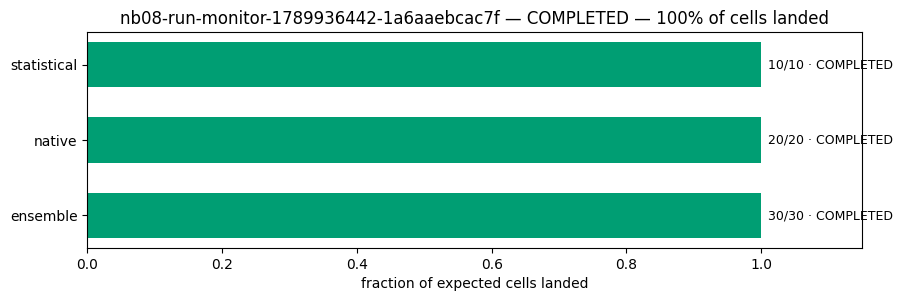

final: status=COMPLETED  60/60 cells
[  812s] probed after 798s quiet → escalated=True disagreement=False  statistical=RUNNING_CONFIRMED  native=TRUST_REGISTRY  ensemble=TRUST_REGISTRY
[  936s] probed after 922s quiet → escalated=True disagreement=False  statistical=RUNNING_CONFIRMED  native=TRUST_REGISTRY  ensemble=TRUST_REGISTRY
[ 1060s] probed after 1046s quiet → escalated=True disagreement=False  statistical=RUNNING_CONFIRMED  native=TRUST_REGISTRY  ensemble=TRUST_REGISTRY
[ 1184s] probed after 1170s quiet → escalated=True disagreement=False  statistical=RUNNING_CONFIRMED  native=TRUST_REGISTRY  ensemble=TRUST_REGISTRY
[ 1308s] probed after 1294s quiet → escalated=True disagreement=False  statistical=RUNNING_CONFIRMED  native=TRUST_REGISTRY  ensemble=TRUST_REGISTRY
[ 1430s] probed after 1416s quiet → escalated=True disagreement=False  statistical=RUNNING_CONFIRMED  native=TRUST_REGISTRY  ensemble=TRUST_REGISTRY
[ 1554s] probed after 1540s quiet → escalated=True disagreement=True  s

In [5]:
import matplotlib.pyplot as plt
from IPython.display import clear_output

from scale_forecasting.review import monitor_run, plot_progress

# The canonical terminal set (mirrors probes.vocabulary._TERMINAL) — CANCELLED included, so a
# cancelled run ends the loop instead of polling on to the wall-clock cap.
_TERMINAL = {"COMPLETED", "FAILED", "PARTIAL", "CANCELLED"}
POLL_S = 15               # seconds between registry polls
MAX_WALL_S = 2700         # hard cap so a stalled backend can never hang the notebook
QUIET_ESCALATE_S = 300    # a family quiet this long earns a runtime probe
PROBE_EVERY_S = 120       # ...but never probe more often than this


def quietest(progress):
    """Seconds since the longest-silent *unfinished* family last wrote to the registry."""
    ages = [
        f.quiet_seconds
        for f in progress.families
        if f.quiet_seconds is not None and (f.status or "").upper() not in _TERMINAL
    ]
    return max(ages) if ages else 0.0


start = time.monotonic()
deadline = start + MAX_WALL_S
last_probe = None
seen = {}     # family → the status we last logged, so a transition is recorded once
events = []   # clear_output keeps only the final frame, so the story is accumulated here

while True:
    # Cheap tier: registry reads only. quiet_seconds rides along for free.
    progress = monitor_run(RUN_ID, settings=settings)
    elapsed = time.monotonic() - start
    quiet = quietest(progress)
    due = last_probe is None or (time.monotonic() - last_probe) >= PROBE_EVERY_S
    if quiet >= QUIET_ESCALATE_S and due and progress.status not in _TERMINAL:
        # Quiet long enough to be worth a real answer — ask the runtimes themselves.
        progress = monitor_run(RUN_ID, probe=True, settings=settings)
        last_probe = time.monotonic()
        report = progress.probe
        verdicts = "  ".join(f"{v.family}={v.verdict}" for v in report.families if v.verdict)
        events.append(
            f"[{elapsed:5.0f}s] probed after {quiet:.0f}s quiet → "
            f"escalated={report.escalated} disagreement={report.disagreement}  {verdicts}"
        )
    for f in progress.families:
        if seen.get(f.family) != f.status:
            events.append(f"[{elapsed:5.0f}s] {f.family}: {seen.get(f.family) or '—'} → {f.status}")
            seen[f.family] = f.status
    clear_output(wait=True)
    if progress.families:
        plot_progress(progress)  # probe verdicts, when present, replace the age in the bar labels
        plt.show()
    pct = f"{progress.fraction:.0%}" if progress.fraction is not None else "n/a"
    print(f"[{elapsed:5.0f}s] status={progress.status}  "
          f"{progress.n_done}/{progress.n_expected} cells ({pct})  quiet={quiet:4.0f}s")
    if events:
        print("\n".join(events[-10:]))  # the log survives the redraw; the frames do not
    if not worker.is_alive() or progress.status in _TERMINAL or time.monotonic() >= deadline:
        break
    time.sleep(POLL_S)

# The launch thread returns when the run finishes, but registry rows are async-visible
# (Storage Write API) — let them settle, then draw one final frame of the end state.
worker.join(timeout=max(0.0, deadline - time.monotonic()))
time.sleep(10)
progress = monitor_run(RUN_ID, settings=settings)
clear_output(wait=True)
if progress.families:
    plot_progress(progress)
    plt.show()
print(f"final: status={progress.status}  {progress.n_done}/{progress.n_expected} cells")
if events:
    print("\n".join(events[-10:]))
if "error" in launch:
    raise launch["error"]  # the run failed on its thread — surface it now

## Next — review the finished run

The run above is now on the registry under `RUN_ID`. Open **[09 · Review run](09_review_run.ipynb)**, paste that `run_id` into its parameters cell (or let it auto-pick the most recent run), and get the data-science review: the leaderboard, the metric distribution across series, each ensemble's lift over the best base model, and the execution timeline of the family DAG.